In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded")

Libraries Loaded


In [2]:
df = pd.read_csv("covid_data.csv")

df.head()

,Continent,Country,Population,Cases.New,Cases.Active,Cases.Critical,Cases.Recovered,Cases.1M_pop,Cases.Total,Deaths.New,Deaths.1M_pop,Deaths.Total,Tests.1M_pop,Tests.Total,Day,Time
0,North-America,Anguilla,15230.0,NaN,13.0,4.0,3879.0,256336.0,3904,NaN,788.0,12.0,3373736.0,51382.0,2023-07-07,2023-07-07T17:30:09+00:00
1,North-America,Saint-Pierre-Miquelon,5759.0,NaN,1001.0,1.0,2449.0,599410.0,3452,NaN,347.0,2.0,4410488.0,25400.0,2023-07-07,2023-07-07T17:30:09+00:00
2,Africa,Saint-Helena,6115.0,NaN,2164.0,NaN,2.0,354211.0,2166,NaN,NaN,NaN,NaN,NaN,2023-07-07,2023-07-07T17:30:09+00:00
3,South-America,Falkland-Islands,3539.0,NaN,0.0,NaN,1930.0,545352.0,1930,NaN,NaN,NaN,2439107.0,8632.0,2023-07-07,2023-07-07T17:30:09+00:00
4,North-America,Montserrat,4965.0,NaN,19.0,NaN,1376.0,282578.0,1403,NaN,1611.0,8.0,3577442.0,17762.0,2023-07-07,2023-07-07T17:30:09+00:00


In [3]:
df.columns

Index(['Continent', 'Country', 'Population', 'Cases.New', 'Cases.Active',
       'Cases.Critical', 'Cases.Recovered', 'Cases.1M_pop', 'Cases.Total',
       'Deaths.New', 'Deaths.1M_pop', 'Deaths.Total', 'Tests.1M_pop',
       'Tests.Total', 'Day', 'Time'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Continent        236 non-null    object 
 1   Country          238 non-null    object 
 2   Population       229 non-null    float64
 3   Cases.New        111 non-null    float64
 4   Cases.Active     218 non-null    float64
 5   Cases.Critical   130 non-null    float64
 6   Cases.Recovered  216 non-null    float64
 7   Cases.1M_pop     230 non-null    float64
 8   Cases.Total      238 non-null    int64  
 9   Deaths.New       35 non-null     float64
 10  Deaths.1M_pop    225 non-null    float64
 11  Deaths.Total     233 non-null    float64
 12  Tests.1M_pop     213 non-null    float64
 13  Tests.Total      213 non-null    float64
 14  Day              238 non-null    object 
 15  Time             238 non-null    object 
dtypes: float64(11), int64(1), object(4)
memory usage: 29.9+ KB


In [5]:
df.describe()

,Population,Cases.New,Cases.Active,Cases.Critical,Cases.Recovered,Cases.1M_pop,Cases.Total,Deaths.New,Deaths.1M_pop,Deaths.Total,Tests.1M_pop,Tests.Total
count,2.290000e+02,111.000000,2.180000e+02,130.000000,2.160000e+02,230.000000,2.380000e+02,35.000000,225.000000,2.330000e+02,2.130000e+02,2.130000e+02
mean,3.469404e+07,214.918919,2.195988e+05,623.861538,9.030436e+06,198232.439130,8.712698e+06,8.028571,1255.986667,8.881881e+04,2.140122e+06,3.285101e+07
std,1.386374e+08,544.987875,1.722985e+06,3669.044268,5.129814e+07,200149.367416,5.093251e+07,16.707669,1289.427861,5.077829e+05,3.639239e+06,1.193558e+08
min,7.990000e+02,1.000000,0.000000e+00,1.000000,2.000000e+00,16.000000,9.000000e+00,0.000000,2.000000,1.000000e+00,5.093000e+03,7.850000e+03
25%,4.454310e+05,7.000000,4.525000e+01,4.000000,2.378000e+04,17877.000000,2.667775e+04,1.000000,175.000000,2.250000e+02,1.972150e+05,3.478150e+05
50%,5.797805e+06,23.000000,9.225000e+02,12.500000,2.594205e+05,126361.000000,2.269655e+05,2.000000,837.000000,2.570000e+03,8.851190e+05,2.226216e+06
75%,2.210284e+07,105.000000,9.979000e+03,52.750000,1.793834e+06,322602.250000,1.557395e+06,4.000000,2059.000000,1.805700e+04,2.439107e+06,1.308345e+07
max,1.448471e+09,4490.000000,2.055284e+07,37266.000000,6.637565e+08,713686.000000,6.912076e+08,86.000000,6552.000000,6.898266e+06,2.330212e+07,1.180836e+09


In [6]:
df.isnull().sum()

Continent            2
Country              0
Population           9
Cases.New          127
Cases.Active        20
Cases.Critical     108
Cases.Recovered     22
Cases.1M_pop         8
Cases.Total          0
Deaths.New         203
Deaths.1M_pop       13
Deaths.Total         5
Tests.1M_pop        25
Tests.Total         25
Day                  0
Time                 0
dtype: int64

In [7]:
df.fillna(0, inplace=True)

In [10]:
df['Day'] = pd.to_datetime(df['Day'])

In [11]:
df['year'] = df['Day'].dt.year
df['month'] = df['Day'].dt.month

In [12]:
cases_trend = df.groupby('Day')['Cases.New'].sum()

cases_trend.head()

Day
2023-07-07    23856.0
Name: Cases.New, dtype: float64

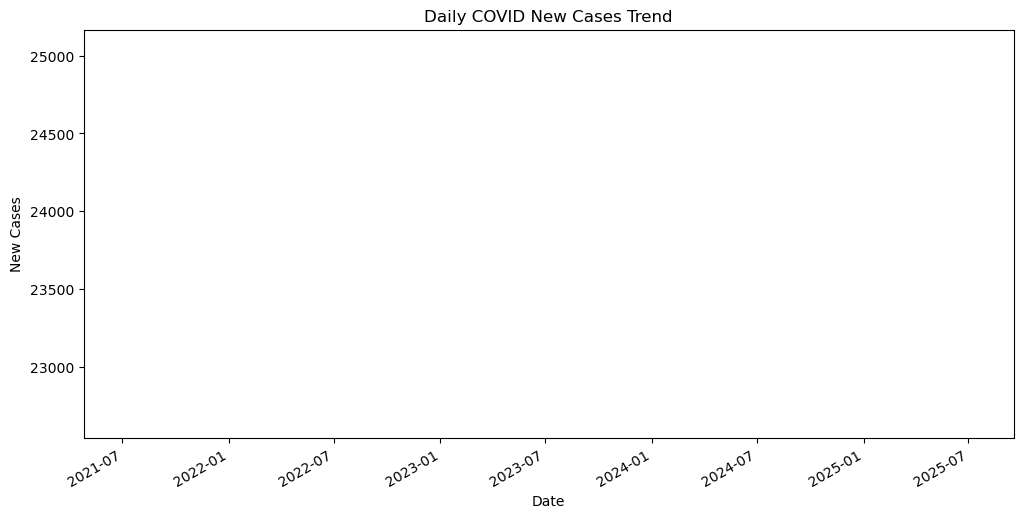

In [13]:
plt.figure(figsize=(12,6))
cases_trend.plot()
plt.title("Daily COVID New Cases Trend")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

In [14]:
death_trend = df.groupby('Day')['Deaths.New'].sum()

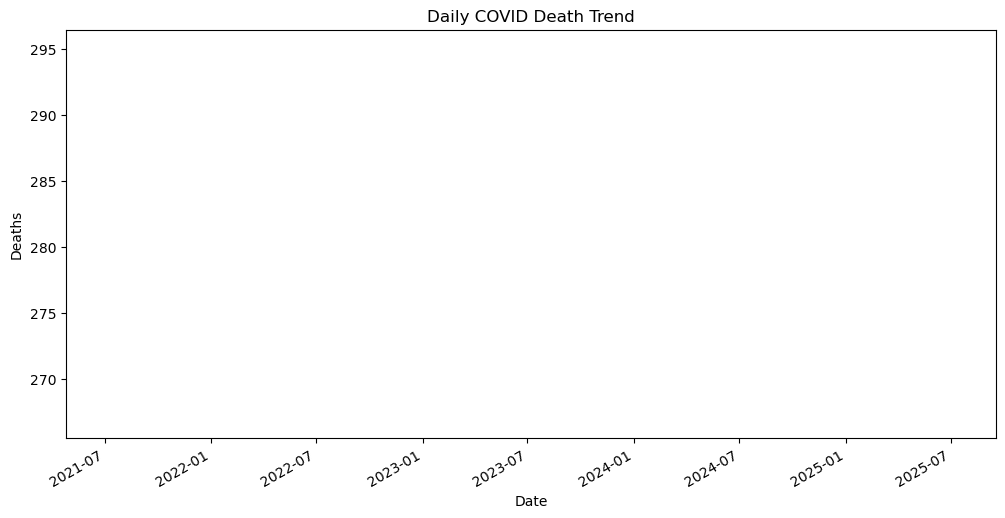

In [15]:
plt.figure(figsize=(12,6))
death_trend.plot()
plt.title("Daily COVID Death Trend")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.show()

In [16]:
top_cases = df.groupby('Country')['Cases.Total'].max().sort_values(ascending=False)

top_cases.head(10)

Country
All              691207603
Europe           249686413
Asia             218288029
North-America    127029174
USA              107352160
South-America     68833139
India             44994407
France            40138560
Germany           38428685
Brazil            37682660
Name: Cases.Total, dtype: int64

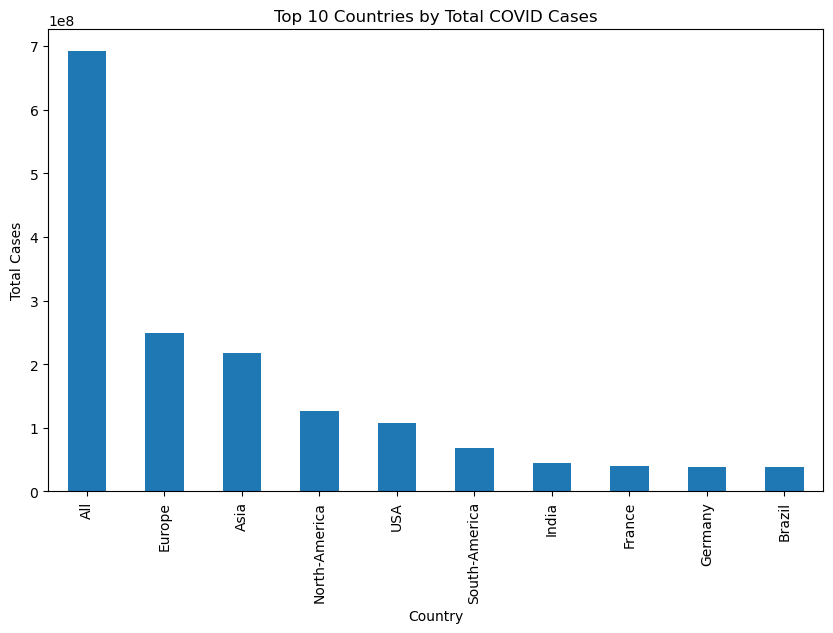

In [17]:
plt.figure(figsize=(10,6))
top_cases.head(10).plot(kind='bar')
plt.title("Top 10 Countries by Total COVID Cases")
plt.ylabel("Total Cases")
plt.show()

In [18]:
recovery = df.groupby('Country')['Cases.Recovered'].max().sort_values(ascending=False)

recovery.head(10)

Country
All              663756499.0
Europe           245815297.0
Asia             201956901.0
North-America    123016875.0
USA              105509635.0
South-America     66485149.0
India             44461044.0
France            39954415.0
Germany           38240600.0
Brazil            36249161.0
Name: Cases.Recovered, dtype: float64

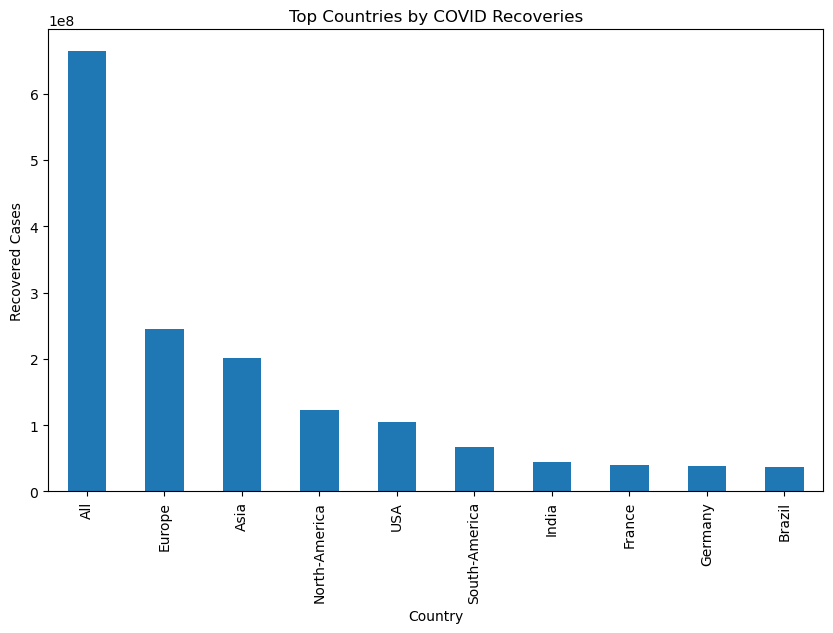

In [19]:
plt.figure(figsize=(10,6))
recovery.head(10).plot(kind='bar')
plt.title("Top Countries by COVID Recoveries")
plt.ylabel("Recovered Cases")
plt.show()

Key Insights:

-COVID cases increased rapidly during early pandemic waves
-Certain countries recorded significantly higher case counts
-Death trends follow similar patterns as case spikes